## Analiza uzyskanych wyników modelu

In [1]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_name = 'results/model_sym wpływ_parametry_v2.csv'

print("Rozpoczynam wczytywanie i parsowanie pliku NetLogo...")

with open(file_name, 'r', encoding='utf-8', errors='ignore') as f:
    reader = list(csv.reader(f))

row_run = reader[6]
row_eps = reader[7]
row_thresh = reader[8]
row_data = reader[12]

num_cols = len(row_run)
runs_data = []

# Każdy 'run' w pliku spreadsheet zajmuje dokładnie 3 kolumny: 
# [krok czasowy], [count turtles with [adopted?]], [mean [opinion] of turtles]
for i in range(1, num_cols, 3):
    if i >= len(row_data):
        break
    
    run_num = row_run[i]
    eps_val = row_eps[i]
    thresh_val = row_thresh[i]
    
    step = row_data[i]
    adopted = row_data[i+1] if i+1 < len(row_data) else None
    mean_op = row_data[i+2] if i+2 < len(row_data) else None
    
    # Zapisujemy dane tylko dla poprawnie zainicjalizowanych kolumn symulacji
    if run_num:
        runs_data.append({
            'run_number': int(run_num),
            'epsilon': float(eps_val),
            'average_threshold': float(thresh_val),
            'final_step': int(step) if step else None,
            'adopted_count': int(adopted) if adopted else None,
            'mean_opinion': float(mean_op) if mean_op else None
        })

df_runs = pd.DataFrame(runs_data)
print(f"Pomyślnie sparsowano dane z {len(df_runs)} przebiegów symulacji.")

# 3. Tworzenie tabeli przestawnej (Pivot Table) wyliczającej średnią z powtórzeń
pivot_adopted = df_runs.pivot_table(
    index='epsilon', 
    columns='average_threshold', 
    values='adopted_count', 
    aggfunc='mean'
)

# Opcjonalne zapisanie uśrednionych danych do czystego pliku CSV
pivot_adopted.to_csv('wyniki_usrednione_czyste.csv')
print("Zapisano uśrednione wyniki do pliku: wyniki_usrednione_czyste.csv")

Rozpoczynam wczytywanie i parsowanie pliku NetLogo...
Pomyślnie sparsowano dane z 630 przebiegów symulacji.
Zapisano uśrednione wyniki do pliku: wyniki_usrednione_czyste.csv


## Mapa ciepła

<>:13: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:15: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:13: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:15: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/var/folders/8t/36p_gbqs38z84f6j3v16yj480000gn/T/ipykernel_92882/3839489344.py:13: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  ax1.set_title('Wpływ tolerancji ($\epsilon$) i progu podatności ($\\tau$) na zasięg dyfuzji', fontsize=13, pad=15)
/var/folders/8t/36p_gbqs38z84f6j3v16y

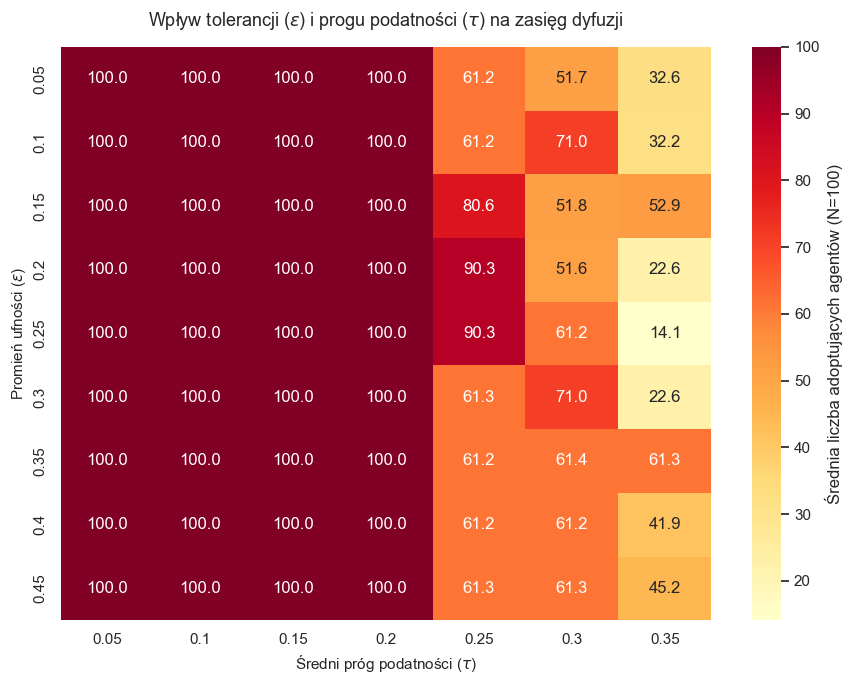

In [8]:
sns.set_theme(style="whitegrid")
fig1, ax1 = plt.subplots(figsize=(9, 7))

sns.heatmap(
    pivot_adopted, 
    annot=True, 
    fmt=".1f", 
    cmap="YlOrRd", 
    cbar_kws={'label': 'Średnia liczba adoptujących agentów (N=100)'}, 
    ax=ax1
)

ax1.set_title('Wpływ tolerancji ($\epsilon$) i progu podatności ($\\tau$) na zasięg dyfuzji', fontsize=13, pad=15)
ax1.set_xlabel('Średni próg podatności ($\\tau$)', fontsize=11)
ax1.set_ylabel('Promień ufności ($\epsilon$)', fontsize=11)

plt.tight_layout()
plt.savefig('heatmap_diffusion_v2.png', dpi=300)
plt.show()

## Wykres liniowy trendów

<>:14: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:15: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:14: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:15: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/var/folders/8t/36p_gbqs38z84f6j3v16yj480000gn/T/ipykernel_92882/391017812.py:14: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  ax2.set_title('Średni zasięg adopcji w funkcji promienia ufności ($\epsilon$)', fontsize=13, pad=15)
/var/folders/8t/36p_gbqs38z84f6j3v16yj480000gn/T/ipy

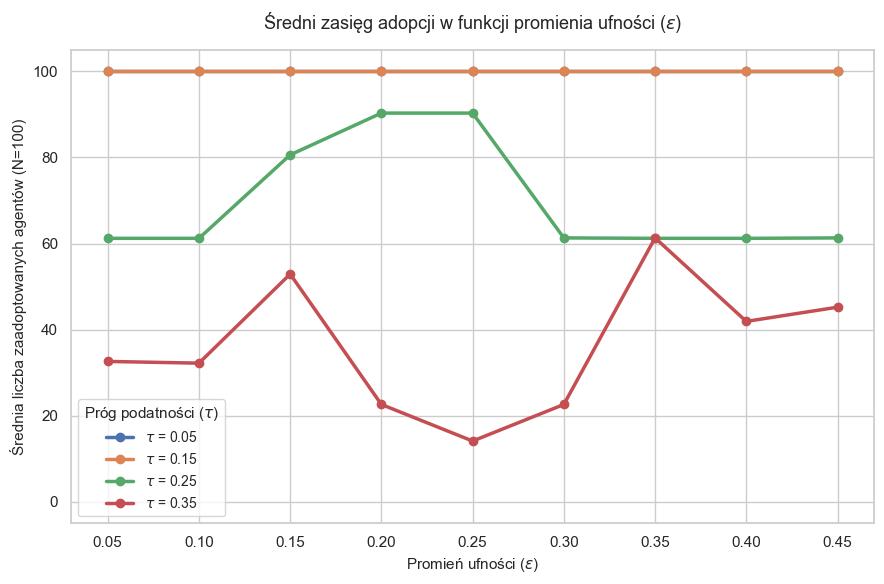

In [6]:
fig2, ax2 = plt.subplots(figsize=(9, 6))

# Definiujemy wybrane progi tau, które chcemy pokazać jako linie trendu
selected_thresholds = [0.05, 0.15, 0.25, 0.35]

for thresh in selected_thresholds:
    # Filtrowanie danych dla danego progu tau i grupowanie po epsilonie
    sub_df = df_runs[df_runs['average_threshold'] == thresh]
    grouped = sub_df.groupby('epsilon')['adopted_count'].mean()
    
    # Rysowanie linii dla wybranego progu
    ax2.plot(grouped.index, grouped.values, marker='o', linewidth=2.5, label=f'$\\tau$ = {thresh}')

ax2.set_title('Średni zasięg adopcji w funkcji promienia ufności ($\epsilon$)', fontsize=13, pad=15)
ax2.set_xlabel('Promień ufności ($\epsilon$)', fontsize=11)
ax2.set_ylabel('Średnia liczba zaadoptowanych agentów (N=100)', fontsize=11)
ax2.set_ylim(-5, 105) # Stały zakres Y, aby ładnie pokazać skok do 100
ax2.legend(title='Próg podatności ($\\tau$)', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.savefig('line_plot_diffusion_v2.png', dpi=300)
plt.show()